# BB84 Quantum Key Distribution — local simulation

A runnable, end-to-end simulation of the **BB84** protocol using Qiskit statevectors for the
quantum layer. It demonstrates the full pipeline:

> generate → encode → transmit → measure → **sift** → estimate **QBER** → **error correction** → **privacy amplification** → secret key

and includes an **intercept-resend eavesdropper (Eve)**, whose disturbance shows up as an elevated
error rate. Two scenarios are run: a quiet channel (key succeeds) and an eavesdropped channel
(detected and aborted).

**Bases:** `Z` = rectilinear (`+`), `X` = diagonal (`×`). In `Z`: bit 0 → |0⟩, bit 1 → |1⟩.
In `X`: bit 0 → |+⟩, bit 1 → |−⟩.

Run top to bottom. Every knob lives in the config cell below.

## 0 · Setup and configuration

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

# ---- Every tunable parameter lives here ----
N_QUBITS = 2048              # number of qubits (photons) Alice sends
CHANNEL_NOISE = 0.04         # bit-flip probability on Bob's detector (kept below the abort threshold)
QBER_SAMPLE_FRACTION = 0.30  # fraction of the sifted key sacrificed to estimate QBER
ABORT_THRESHOLD = 0.11       # standard BB84 security bound; abort if measured QBER exceeds it
N_PASSES = 2                 # Cascade passes. 2 = the chosen default; 4 reaches zero residual ~always
SECURITY_BITS = 32           # privacy-amplification safety margin
SEED = 0                     # fixed seed -> fully reproducible top-to-bottom run

print(f"Config: {N_QUBITS} qubits, noise={CHANNEL_NOISE}, abort>{ABORT_THRESHOLD}, "
      f"Cascade passes={N_PASSES}")

Config: 2048 qubits, noise=0.04, abort>0.11, Cascade passes=2


## 1 · Quantum primitives

`encode` prepares a single qubit carrying one bit in a chosen basis. `measure` reads it out in a
(possibly different) basis. Measurement is done from the **actual statevector probabilities** and
sampled with our seeded RNG, so the whole notebook is reproducible.

In [2]:
def encode(bit, basis):
    """Prepare one qubit carrying `bit` in `basis` ('Z' or 'X'). No measurement attached."""
    qc = QuantumCircuit(1)
    if basis == "Z":          # rectilinear: 0 -> |0>, 1 -> |1>
        if bit == 1:
            qc.x(0)
    else:                     # diagonal: 0 -> |+>, 1 -> |->
        if bit == 0:
            qc.h(0)
        else:
            qc.x(0)
            qc.h(0)
    return qc


def measure(prep_qc, basis, rng):
    """Measure a prepared qubit in `basis`. Returns 0/1 sampled from the statevector."""
    mqc = prep_qc.copy()
    if basis == "X":
        mqc.h(0)              # rotate the diagonal basis onto the computational one
    probs = Statevector(mqc).probabilities()   # [P(0), P(1)]
    if rng.random() < probs[1]:
        return 1
    return 0

## 2 · The channel (with optional eavesdropper)

Alice's qubit travels to Bob. If `eavesdrop` is on, **Eve** intercepts it: she measures in her own
random basis (which collapses the state), then re-prepares and forwards a fresh qubit. Whenever her
basis disagrees with Alice's, she corrupts the state — this is what makes her detectable. A simple
bit-flip models channel/detector noise.

In [3]:
def transmit(alice_bit, alice_basis, bob_basis, eve_basis, eavesdrop, noise, rng):
    """Send one qubit Alice -> (Eve?) -> Bob. Returns Bob's measured bit."""
    prep = encode(alice_bit, alice_basis)
    if eavesdrop:
        eve_bit = measure(prep, eve_basis, rng)   # Eve's measurement collapses the qubit
        prep = encode(eve_bit, eve_basis)         # she re-prepares in her basis and forwards
    bob_bit = measure(prep, bob_basis, rng)
    if rng.random() < noise:                      # detector / channel bit-flip
        bob_bit ^= 1
    return bob_bit

## 3 · Run the quantum phase and sift

Alice and Bob each pick random bits/bases; Bob measures everything. **Sifting** keeps only the
positions where their bases happened to match (~50%) — the rest is discarded over the public channel.

In [4]:
def run_quantum_phase(n, eavesdrop, noise, rng):
    """Transmit n qubits and sift. Returns (alice_sifted, bob_sifted, record)."""
    alice_bits  = rng.integers(0, 2, n)
    alice_bases = rng.choice(["Z", "X"], n)
    bob_bases   = rng.choice(["Z", "X"], n)
    eve_bases   = rng.choice(["Z", "X"], n)

    bob_bits = np.empty(n, dtype=int)
    for i in range(n):
        bob_bits[i] = transmit(alice_bits[i], alice_bases[i], bob_bases[i],
                               eve_bases[i], eavesdrop, noise, rng)

    matched = alice_bases == bob_bases            # sift: keep matching-basis positions
    record = {"alice_bits": alice_bits, "alice_bases": alice_bases,
              "bob_bits": bob_bits, "bob_bases": bob_bases, "matched": matched}
    return alice_bits[matched], bob_bits[matched], record


rng = np.random.default_rng(SEED)
a_sift, b_sift, rec = run_quantum_phase(N_QUBITS, eavesdrop=False, noise=CHANNEL_NOISE, rng=rng)

print(f"Sent {N_QUBITS} qubits -> sifted key length {len(a_sift)} "
      f"({100 * len(a_sift) / N_QUBITS:.1f}% kept)\n")
print(" i | A.bit A.base | B.base B.bit | kept")
print("---+--------------+--------------+-----")
for i in range(12):
    if rec["matched"][i]:
        kept = "yes"
    else:
        kept = "no"
    print(f"{i:2} |   {rec['alice_bits'][i]}     {rec['alice_bases'][i]}    |"
          f"   {rec['bob_bases'][i]}     {rec['bob_bits'][i]}    | {kept}")

Sent 2048 qubits -> sifted key length 1043 (50.9% kept)

 i | A.bit A.base | B.base B.bit | kept
---+--------------+--------------+-----
 0 |   1     X    |   Z     1    | no
 1 |   1     Z    |   Z     1    | yes
 2 |   1     Z    |   Z     1    | yes
 3 |   0     Z    |   X     1    | no
 4 |   0     X    |   X     0    | yes
 5 |   0     Z    |   Z     0    | yes
 6 |   0     X    |   Z     0    | no
 7 |   0     Z    |   X     1    | no
 8 |   0     Z    |   X     0    | no
 9 |   1     X    |   X     1    | yes
10 |   1     Z    |   X     1    | no
11 |   1     X    |   X     1    | yes


## 4 · Estimate QBER and the abort gate

Alice and Bob publicly compare a random sample of their sifted bits to estimate the **quantum bit
error rate**. On a quiet channel this sits near the noise floor; an intercept-resend Eve pushes it
toward ~25%. If it exceeds the security threshold (~11%), they abort.

In [5]:
def estimate_qber(a_sift, b_sift, sample_fraction, rng):
    """Sacrifice a random sample to estimate QBER. Returns (qber, kept_indices)."""
    n = len(a_sift)
    perm = rng.permutation(n)
    n_sample = int(sample_fraction * n)
    sample, keep = perm[:n_sample], perm[n_sample:]
    qber = float(np.mean(a_sift[sample] != b_sift[sample]))
    return qber, keep


for eavesdrop in (False, True):
    rng = np.random.default_rng(SEED)
    a, b, _ = run_quantum_phase(N_QUBITS, eavesdrop, CHANNEL_NOISE, rng)
    qber, _ = estimate_qber(a, b, QBER_SAMPLE_FRACTION, rng)
    if qber > ABORT_THRESHOLD:
        verdict = "ABORT (eavesdropper likely)"
    else:
        verdict = "proceed"
    label = "Eve present" if eavesdrop else "quiet channel"
    print(f"{label:14}: QBER = {qber:.3f}  ->  {verdict}")

quiet channel : QBER = 0.058  ->  proceed
Eve present   : QBER = 0.237  ->  ABORT (eavesdropper likely)


## 5 · Error correction — 2-pass Cascade

Bob's sifted key still differs from Alice's at the noise positions. **Cascade** fixes this: split the
key into blocks, compare each block's parity, and binary-search any mismatched block down to the single
flipped bit. A second pass with a fresh permutation and doubled block size catches more; the
**backtracking** step (re-checking earlier blocks once a bit flips) is what gives Cascade its name.

Every revealed parity bit leaks information to Eve, so we count the total — privacy amplification
subtracts it later. Note: **2 passes corrects the bulk but not always all errors** (a real property,
shown in the reliability plot at the end). A verification step guards against amplifying a bad key;
set `N_PASSES = 4` for near-certain convergence.

In [6]:
def cascade(alice, bob, qber, n_passes, rng):
    """2-pass Cascade reconciliation with backtracking. Mutates `bob`; returns bits leaked."""
    n = len(bob)
    leaked = [0]
    k = max(2, int(round(0.73 / max(qber, 1e-3))))   # initial block size from QBER (Cascade heuristic)
    block_of = []                                    # per-pass map: bit index -> its block

    def parity(bits, idx):
        return int(bits[idx].sum() & 1)

    def find_one_error(idx):
        while len(idx) > 1:                          # binary search for the single flipped bit
            leaked[0] += 1
            half = len(idx) // 2
            left = idx[:half]
            if parity(alice, left) != parity(bob, left):
                idx = left
            else:
                idx = idx[half:]
        pos = int(idx[0])
        bob[pos] ^= 1
        return pos

    for p in range(n_passes):
        if p == 0:
            perm = np.arange(n)                      # pass 1 in natural order
        else:
            perm = rng.permutation(n)                # later passes shuffle the key
        mapping = [None] * n
        blocks = []
        for start in range(0, n, k):
            blk = perm[start:start + k]
            blocks.append(blk)
            for i in blk:
                mapping[int(i)] = blk
        block_of.append(mapping)
        leaked[0] += len(blocks)                     # one parity revealed per block

        queue = [blk for blk in blocks if parity(alice, blk) != parity(bob, blk)]
        while queue:
            blk = queue.pop()
            if parity(alice, blk) == parity(bob, blk):
                continue
            pos = find_one_error(blk)
            for mp in block_of:                      # backtrack: every pass holding `pos` may now be odd
                if parity(alice, mp[pos]) != parity(bob, mp[pos]):
                    queue.append(mp[pos])
        k *= 2
    return leaked[0]


# Demo on the quiet-channel key
rng = np.random.default_rng(SEED)
a, b, _ = run_quantum_phase(N_QUBITS, False, CHANNEL_NOISE, rng)
qber, keep = estimate_qber(a, b, QBER_SAMPLE_FRACTION, rng)
alice_key, bob_key = a[keep].copy(), b[keep].copy()

errors_before = int(np.sum(alice_key != bob_key))
leaked = cascade(alice_key, bob_key, max(qber, 0.01), N_PASSES, rng)
errors_after = int(np.sum(alice_key != bob_key))

print(f"Key length entering reconciliation: {len(keep)}")
print(f"Errors before: {errors_before}   after {N_PASSES}-pass Cascade: {errors_after}")
print(f"Bits leaked over public channel: {leaked}")
print(f"Verified identical: {errors_after == 0}")

Key length entering reconciliation: 731
Errors before: 30   after 2-pass Cascade: 0
Bits leaked over public channel: 206
Verified identical: True


## 6 · Privacy amplification — Toeplitz hashing

The reconciled key is correct but partially known to Eve (from leaked parities and her measurements,
bounded via the binary entropy of the QBER). A universal hash — a random **Toeplitz matrix** over
GF(2) — compresses the key to a shorter one about which Eve's expected information is negligible.

In [7]:
def binary_entropy(p):
    if p <= 0 or p >= 1:
        return 0.0
    return -p * np.log2(p) - (1 - p) * np.log2(1 - p)


def toeplitz_hash(key, out_len, seed_bits):
    """Multiply key by a random out_len x n Toeplitz matrix over GF(2)."""
    n = len(key)
    rows = [seed_bits[i - np.arange(n) + (n - 1)] for i in range(out_len)]
    T = np.array(rows)
    return (T @ key) % 2


def privacy_amplify(key, qber, leaked_bits, rng):
    """Shrink the key by leaked + Eve's entropy bound + a safety margin."""
    n = len(key)
    eve_info = int(np.ceil(n * binary_entropy(qber)))
    out_len = n - leaked_bits - eve_info - SECURITY_BITS
    if out_len <= 0:
        return np.array([], dtype=int)
    seed_bits = rng.integers(0, 2, out_len + n - 1)
    return toeplitz_hash(key, out_len, seed_bits)


final_key = privacy_amplify(alice_key, qber, leaked, rng)
print(f"Reconciled {len(alice_key)} bits -> secret key {len(final_key)} bits "
      f"(removed {len(alice_key) - len(final_key)} for leakage + Eve + margin)")
print("First 48 bits:", "".join(map(str, final_key[:48])))

Reconciled 731 bits -> secret key 260 bits (removed 471 for leakage + Eve + margin)
First 48 bits: 011101100011011010100000011000001011011111100010


## 7 · Full pipeline, both scenarios

`run_full_protocol` chains every stage and returns the statistics. Running it on a quiet channel
yields a usable key; running it against Eve trips the abort gate.

In [8]:
def run_full_protocol(eavesdrop, seed, verbose=True):
    rng = np.random.default_rng(seed)

    a_sift, b_sift, _ = run_quantum_phase(N_QUBITS, eavesdrop, CHANNEL_NOISE, rng)
    qber, keep = estimate_qber(a_sift, b_sift, QBER_SAMPLE_FRACTION, rng)
    stats = {"raw": N_QUBITS, "sifted": len(a_sift), "qber": qber,
             "kept_after_sample": len(keep), "aborted": False,
             "corrected": 0, "leaked": 0, "final": 0, "verified": False}

    if qber > ABORT_THRESHOLD:
        stats["aborted"] = True
        if verbose:
            print(f"QBER {qber:.3f} > {ABORT_THRESHOLD} -> ABORT (eavesdropper likely).")
        return stats

    alice_key, bob_key = a_sift[keep].copy(), b_sift[keep].copy()
    leaked = cascade(alice_key, bob_key, max(qber, 0.01), N_PASSES, rng)
    verified = bool(np.array_equal(alice_key, bob_key))
    stats.update({"corrected": len(keep), "leaked": leaked, "verified": verified})

    if not verified:
        if verbose:
            print(f"Reconciliation left residual errors at N_PASSES={N_PASSES}; "
                  f"not safe to amplify. Raise N_PASSES (4 is reliable).")
        return stats

    final_key = privacy_amplify(alice_key, qber, leaked, rng)
    stats["final"] = len(final_key)
    if verbose:
        print(f"raw {N_QUBITS} -> sifted {stats['sifted']} -> kept {len(keep)} "
              f"-> reconciled (0 errors) -> secret key {len(final_key)} bits.")
    return stats


print("Quiet channel:")
clean = run_full_protocol(False, SEED)
print("\nEavesdropped channel:")
eve = run_full_protocol(True, SEED)

Quiet channel:
raw 2048 -> sifted 1043 -> kept 731 -> reconciled (0 errors) -> secret key 260 bits.

Eavesdropped channel:
QBER 0.237 > 0.11 -> ABORT (eavesdropper likely).


## 8 · Visualizing the results

Three views: QBER (quiet vs Eve, many trials), the key-length funnel from raw qubits to final secret
bits, and the Cascade reliability curve that motivates the verification gate.

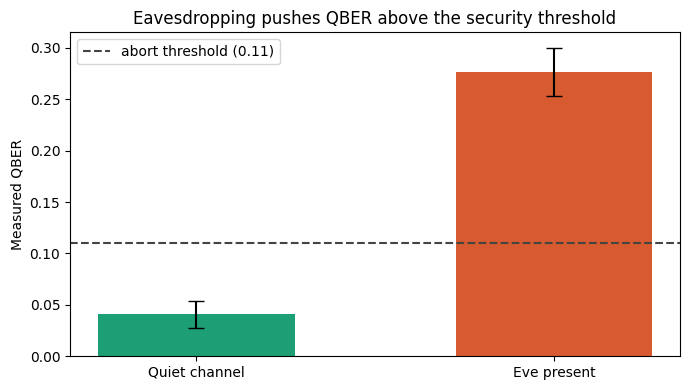

In [9]:
# Plot 1 — QBER distribution: quiet channel vs Eve (many small trials)
TRIAL_N = 400

def quick_qber(eavesdrop, seed):
    rng = np.random.default_rng(seed)
    a, b, _ = run_quantum_phase(TRIAL_N, eavesdrop, CHANNEL_NOISE, rng)
    return float(np.mean(a != b))

clean_q = [quick_qber(False, s) for s in range(15)]
eve_q   = [quick_qber(True,  s) for s in range(15)]

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(["Quiet channel", "Eve present"],
       [np.mean(clean_q), np.mean(eve_q)],
       yerr=[np.std(clean_q), np.std(eve_q)],
       color=["#1D9E75", "#D85A30"], capsize=6, width=0.55)
ax.axhline(ABORT_THRESHOLD, ls="--", color="#444441",
           label=f"abort threshold ({ABORT_THRESHOLD})")
ax.set_ylabel("Measured QBER")
ax.set_title("Eavesdropping pushes QBER above the security threshold")
ax.legend()
plt.tight_layout()
plt.show()

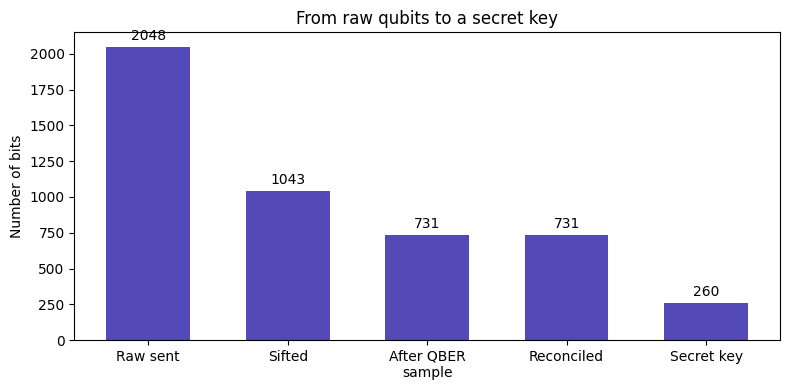

In [10]:
# Plot 2 — key-length funnel for the quiet-channel run
s = run_full_protocol(False, SEED, verbose=False)
stages = ["Raw sent", "Sifted", "After QBER\nsample", "Reconciled", "Secret key"]
values = [s["raw"], s["sifted"], s["kept_after_sample"], s["corrected"], s["final"]]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(stages, values, color="#534AB7", width=0.6)
ax.bar_label(bars, padding=3)
ax.set_ylabel("Number of bits")
ax.set_title("From raw qubits to a secret key")
plt.tight_layout()
plt.show()

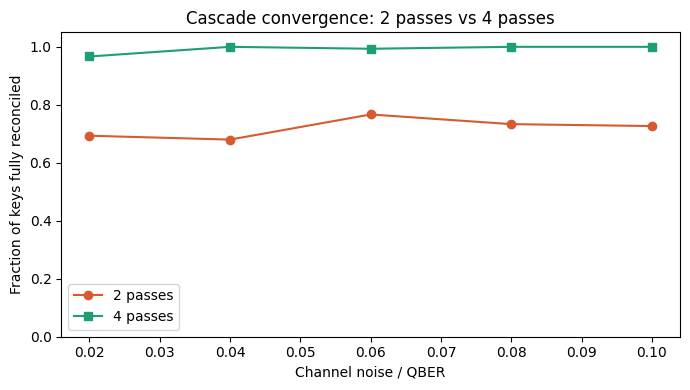

In [11]:
# Plot 3 — Cascade reliability: why 2 passes sometimes needs a verification gate
def cascade_success(noise, n_passes, trials, seed):
    rng = np.random.default_rng(seed)
    ok = 0
    for _ in range(trials):
        a = rng.integers(0, 2, 600)
        b = a.copy()
        b[rng.random(600) < noise] ^= 1
        cascade(a, b, max(noise, 0.01), n_passes, rng)
        if np.array_equal(a, b):
            ok += 1
    return ok / trials

noises = [0.02, 0.04, 0.06, 0.08, 0.10]
succ2 = [cascade_success(x, 2, 150, 1) for x in noises]
succ4 = [cascade_success(x, 4, 150, 1) for x in noises]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(noises, succ2, "o-", color="#D85A30", label="2 passes")
ax.plot(noises, succ4, "s-", color="#1D9E75", label="4 passes")
ax.set_xlabel("Channel noise / QBER")
ax.set_ylabel("Fraction of keys fully reconciled")
ax.set_title("Cascade convergence: 2 passes vs 4 passes")
ax.set_ylim(0, 1.05)
ax.legend()
plt.tight_layout()
plt.show()